**#Importing Necessary Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.metrics import roc_curve, auc
# Initial Settings
warnings.filterwarnings('ignore')
plt.style.use('fivethirtyeight')


**# STEP 1: DATA INGESTION & PRE-EDA (CLEANING)**


In [5]:




# 1. DATA INGESTION (Existing) Loading the PaySim dataset
df = pd.read_csv("C:\\Users\\vasum\\Desktop\\archive\\Pay_financial_fraud.csv")

# 2. REMOVING DUPLICATES (Existing)
df.drop_duplicates(inplace=True)

# 3. HANDLING MISSING VALUES (Imputation)
# Although your current summary shows 0 missing values, 
# adding this ensures robustness for future data updates.
def handle_missing_values(df):
    # Numerical: Fill with median (robust to outliers)
    num_cols = df.select_dtypes(include=[np.number]).columns
    df[num_cols] = df[num_cols].fillna(df[num_cols].median())
    
    # Categorical: Fill with most frequent (mode)
    cat_cols = df.select_dtypes(include=['object']).columns
    for col in cat_cols:
        df[col] = df[col].fillna(df[col].mode()[0])
    return df

df = handle_missing_values(df)

# 4. OUTLIER HANDLING (Capping/Winsorization)
# For financial data, 'amount' often has extreme outliers.
def handle_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    # Cap outliers to the bounds
    df[column] = np.where(df[column] > upper_bound, upper_bound, 
                 np.where(df[column] < lower_bound, lower_bound, df[column]))
    return df

df = handle_outliers(df, 'amount')

# 5. DATA TYPE CONSISTENCY
# Ensure 'step' and 'isFraud' are treated correctly
df['isFraud'] = df['isFraud'].astype(int)
df['isFlaggedFraud'] = df['isFlaggedFraud'].astype(int)

# 6. FEATURE ENGINEERING (Cleaning logic from your notebook)
# Cleaning balance errors: ensuring (Original + Amount) matches (New Balance)
df['errorBalanceOrg'] = df['newbalanceOrig'] + df['amount'] - df['oldbalanceOrg']
df['errorBalanceDest'] = df['oldbalanceDest'] + df['amount'] - df['newbalanceDest']

# 7. CATEGORICAL ENCODING
# Convert 'type' into numerical format for the model
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['type_encoded'] = le.fit_transform(df['type'])

print("Cleaning Complete. Missing Values:", df.isnull().sum().sum())
# Checking for and removing duplicates
duplicates = df.duplicated().sum()
if duplicates > 0:
    df.drop_duplicates(inplace=True)

# Data Audit
print(f"### Data Ingestion Summary ###")
print(f"Total Transactions: {df.shape[0]} | Missing Values: {df.isnull().sum().sum()}")

Cleaning Complete. Missing Values: 0
### Data Ingestion Summary ###
Total Transactions: 6362620 | Missing Values: 0



**# STEP 2: EDA (ANALYSIS & VISUALIZATIONS)**



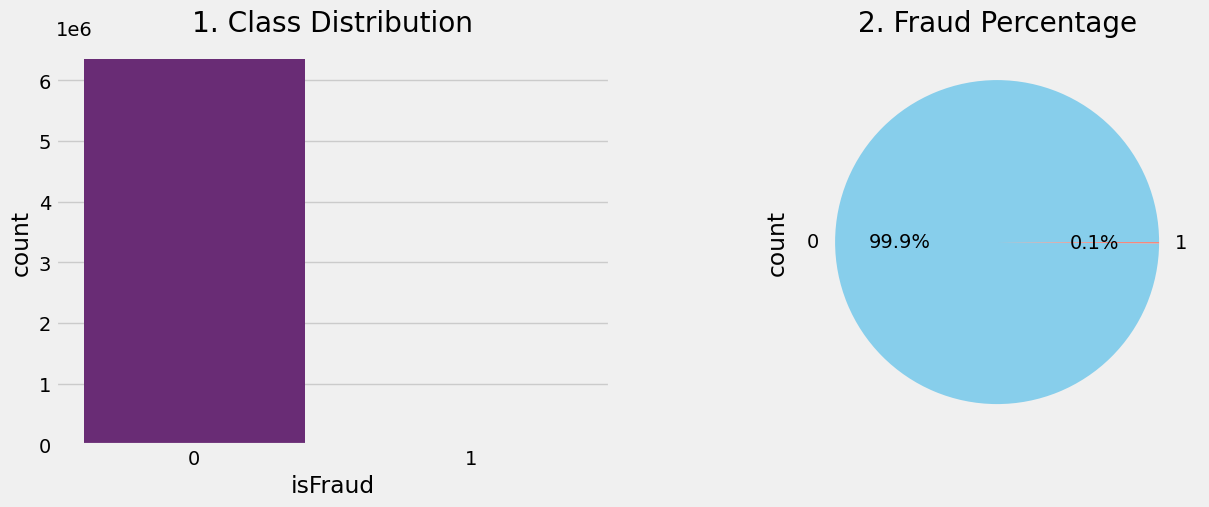

In [6]:
# Visual 1 & 2: Class Imbalance
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
sns.countplot(x='isFraud', data=df, palette='magma')
plt.title('1. Class Distribution')
plt.subplot(1, 2, 2)
df['isFraud'].value_counts().plot.pie(autopct='%1.1f%%', colors=['skyblue', 'salmon'])
plt.title('2. Fraud Percentage')
plt.show()

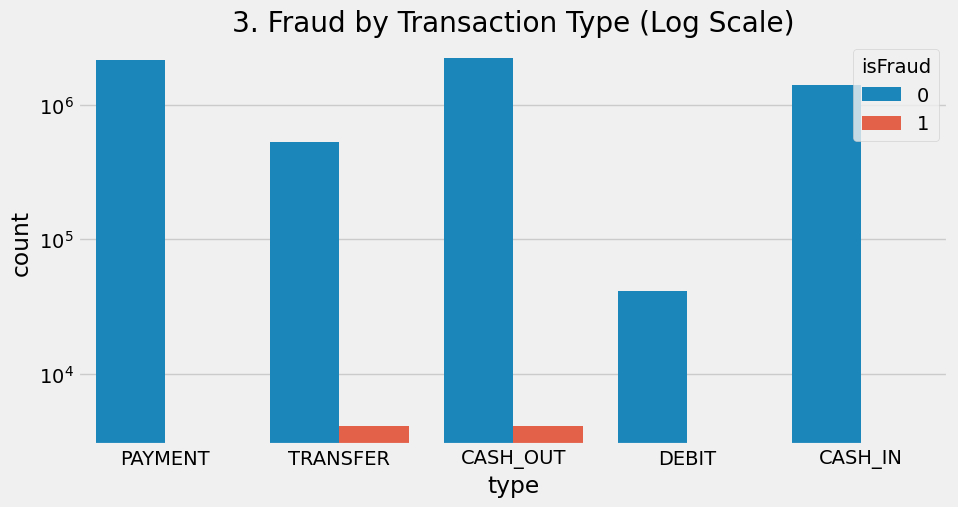

In [7]:
# Visual 3: Fraud by Transaction Type
plt.figure(figsize=(10, 5))
sns.countplot(x='type', hue='isFraud', data=df)
plt.yscale('log')
plt.title('3. Fraud by Transaction Type (Log Scale)')
plt.show()

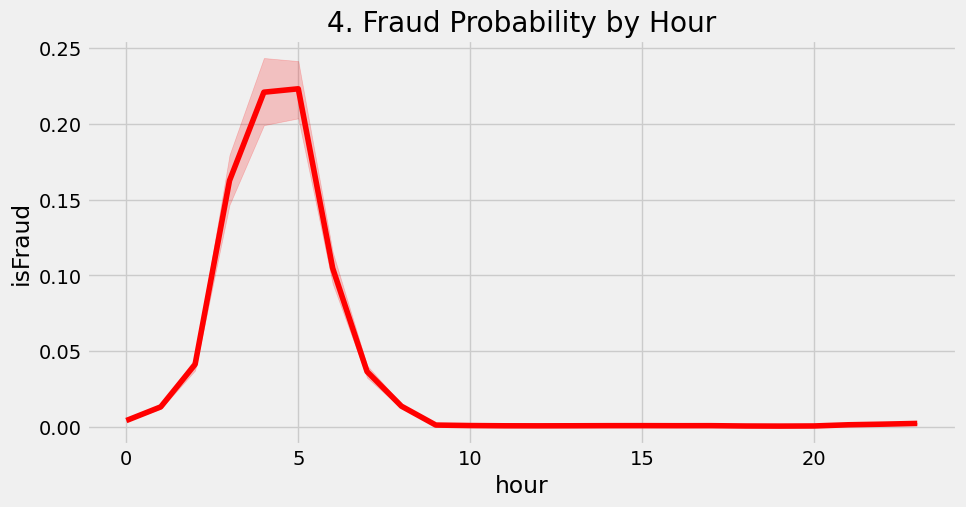

In [8]:
# Visual 4: Hourly Patterns
df['hour'] = df['step'] % 24
plt.figure(figsize=(10, 5))
sns.lineplot(x='hour', y='isFraud', data=df, color='red')
plt.title('4. Fraud Probability by Hour')
plt.show()

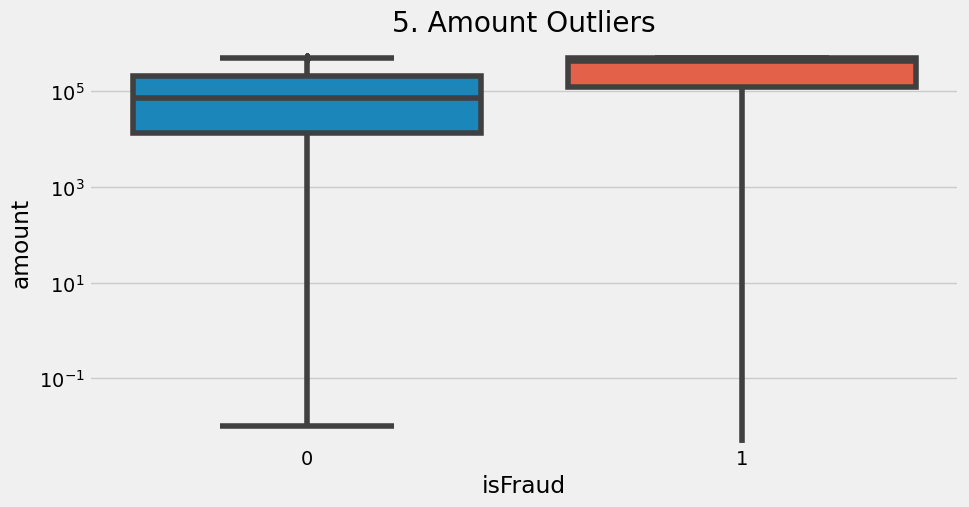

In [9]:
# Visual 5: Amount Outliers
plt.figure(figsize=(10, 5))
sns.boxplot(x='isFraud', y='amount', data=df)
plt.yscale('log')
plt.title('5. Amount Outliers')
plt.show()

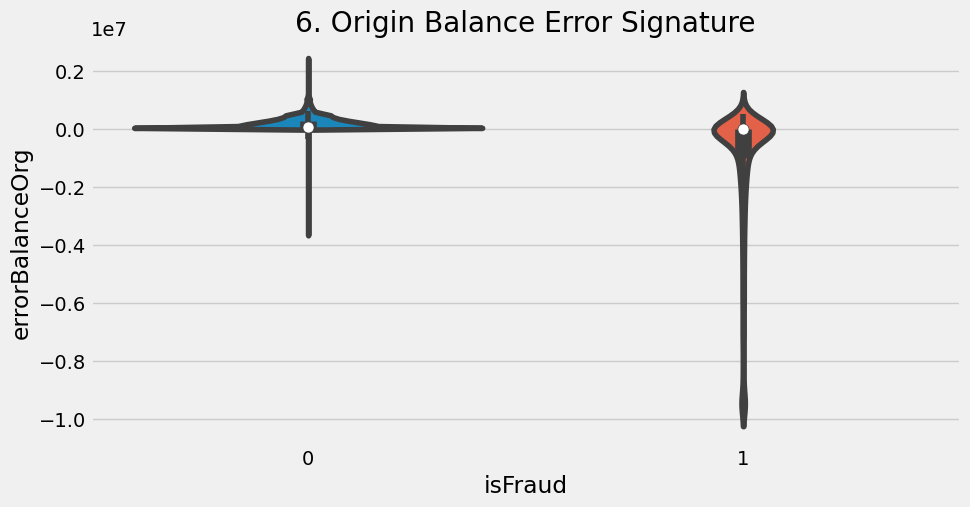

In [10]:
# Visual 6 & 7: Feature Engineering Insights (Balance Errors)
df['errorBalanceOrg'] = df['newbalanceOrig'] + df['amount'] - df['oldbalanceOrg']
df['errorBalanceDest'] = df['oldbalanceDest'] + df['amount'] - df['newbalanceDest']

plt.figure(figsize=(10, 5))
sns.violinplot(x='isFraud', y='errorBalanceOrg', data=df)
plt.title('6. Origin Balance Error Signature')
plt.show()

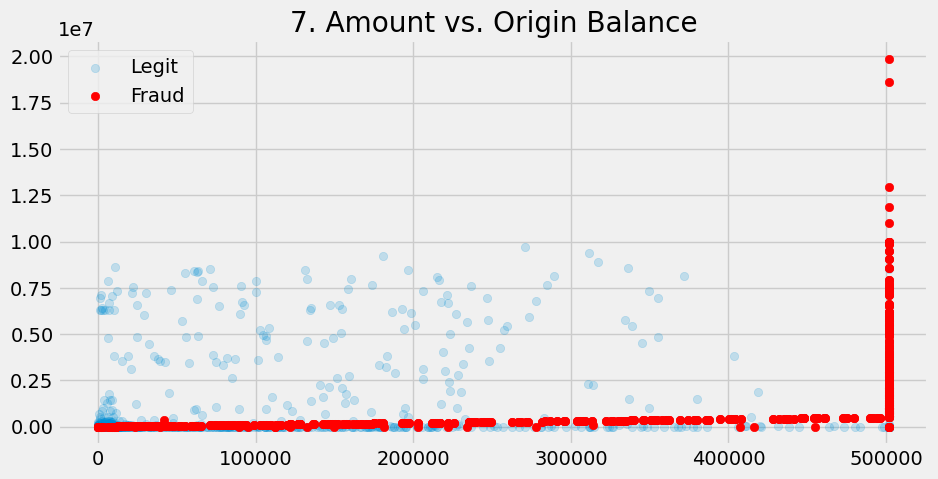

In [11]:
# Visual 8: Amount vs Origin Balance
plt.figure(figsize=(10, 5))
plt.scatter(df[df.isFraud == 0]['amount'][:1000], df[df.isFraud == 0]['oldbalanceOrg'][:1000], label='Legit', alpha=0.2)
plt.scatter(df[df.isFraud == 1]['amount'][:1000], df[df.isFraud == 1]['oldbalanceOrg'][:1000], label='Fraud', color='red')
plt.title('7. Amount vs. Origin Balance')
plt.legend()
plt.show()

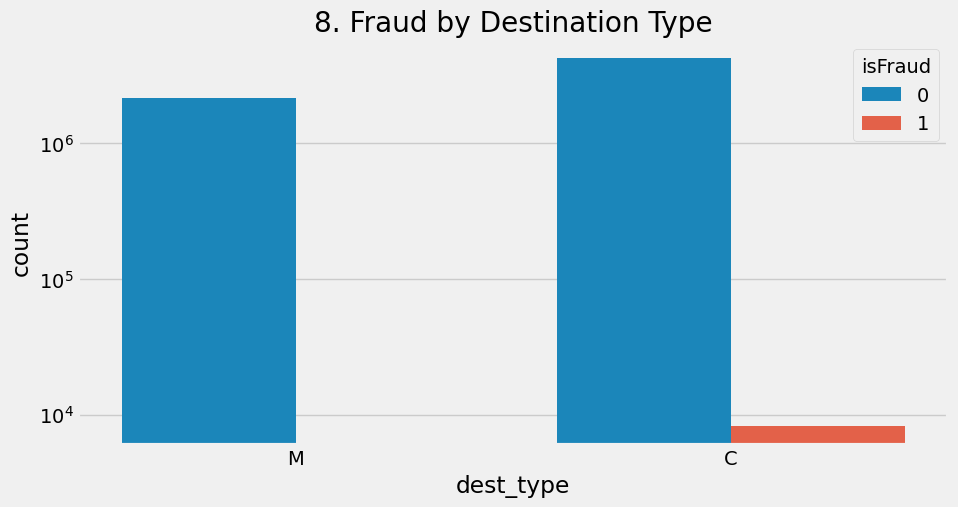

In [12]:
# Visual 9: Destination Type Analysis
df['dest_type'] = df['nameDest'].str[0]
plt.figure(figsize=(10, 5))
sns.countplot(x='dest_type', hue='isFraud', data=df)
plt.yscale('log')
plt.title('8. Fraud by Destination Type')
plt.show()

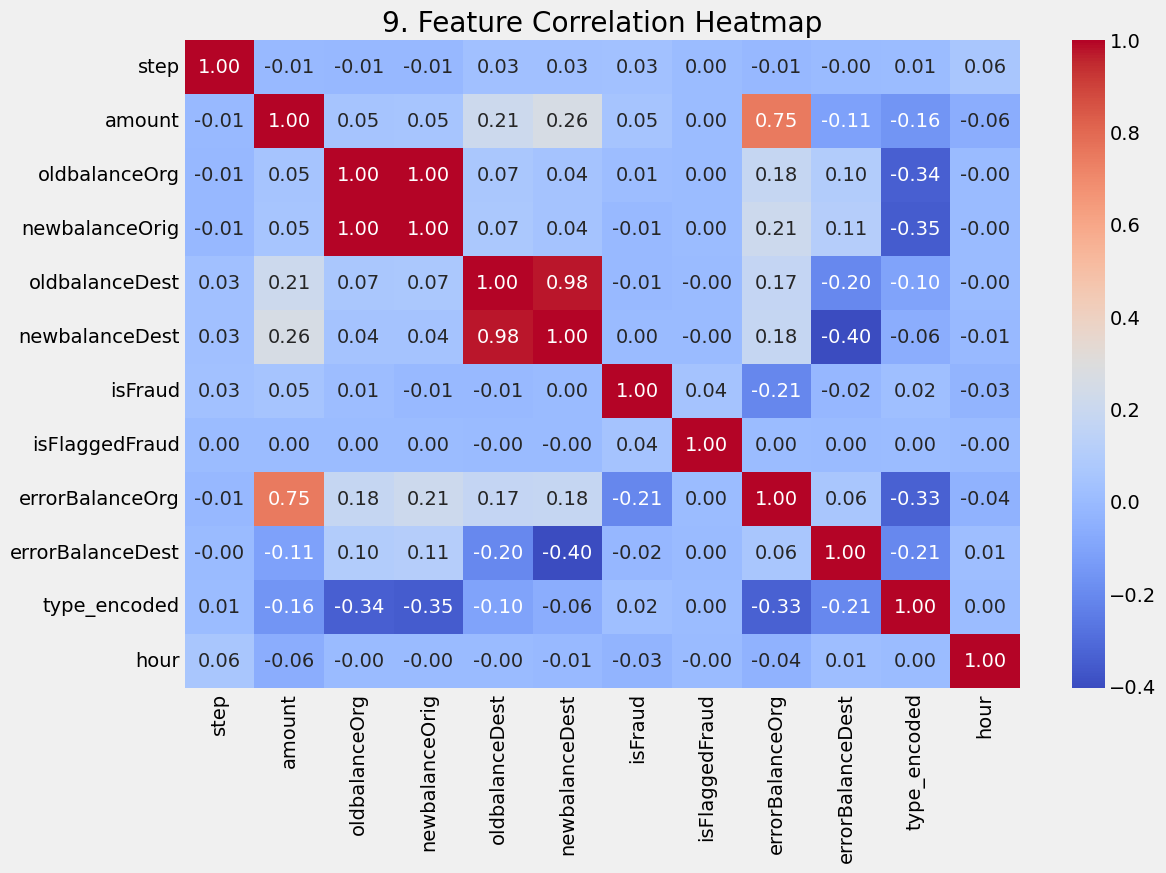

In [13]:
# Visual 10: Correlation Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('9. Feature Correlation Heatmap')
plt.show()

**# STEP 3: POST-EDA (FEATURE ENGINEERING)**

In [14]:

# 1. Drop non-predictive ID columns
df_model = df.drop(['nameOrig', 'nameDest', 'dest_type'], axis=1)


scaler = StandardScaler()
features_to_scale = ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'errorBalanceOrg', 'errorBalanceDest']
df_model[features_to_scale] = scaler.fit_transform(df_model[features_to_scale])

# 2. Encode categorical 'type'
le = LabelEncoder()
df_model['type'] = le.fit_transform(df_model['type'])

**# STEP 4: MODEL TRAINING**

In [15]:
# Define Features (X) and Target (y)
X = df_model.drop('isFraud', axis=1)
y = df_model['isFraud']

# Split Data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("\n### Training Random Forest Model... ###")
model = RandomForestClassifier(n_estimators=50, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1)
model.fit(X_train, y_train)


### Training Random Forest Model... ###


RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=50,
                       n_jobs=-1, random_state=42)

**# STEP 5: MODEL EVALUATION**


### Model Performance Report ###
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.97      1.00      0.98      1643

    accuracy                           1.00   1272524
   macro avg       0.99      1.00      0.99   1272524
weighted avg       1.00      1.00      1.00   1272524



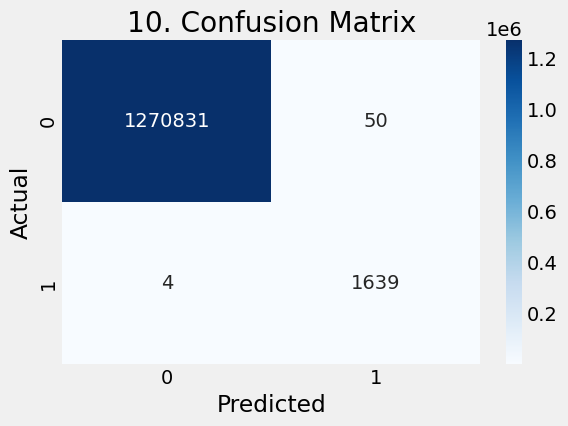

ROC-AUC Score: 0.9998


In [16]:
y_pred = model.predict(X_test)

print("\n### Model Performance Report ###")
print(classification_report(y_test, y_pred))

# Confusion Matrix Visualization
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('10. Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print(f"ROC-AUC Score: {roc_auc_score(y_test, model.predict_proba(X_test)[:,1]):.4f}")

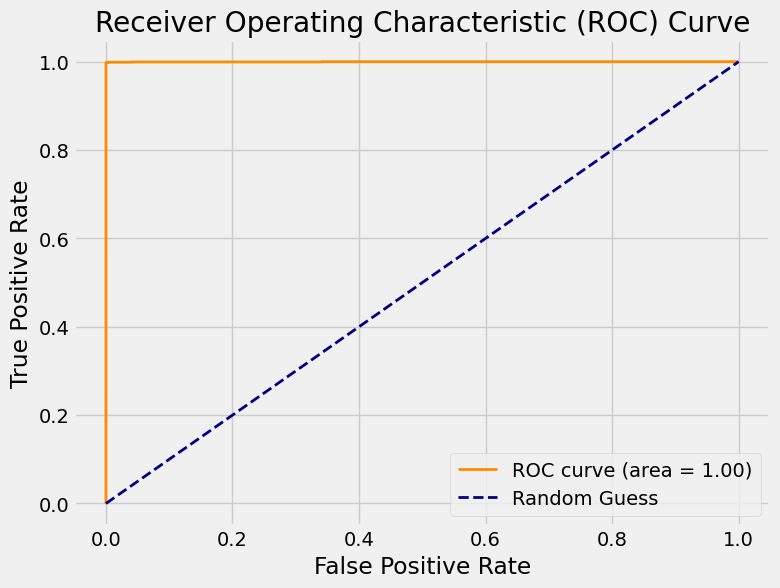

In [17]:
# Calculate probabilities for the positive class
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Calculate ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()